# **Breast_Cancer_Detection**

# **Breast Cancer Wisconsin (Diagnostic) Dataset**

# **1. Data Collection and Initial Exploration**

# Import all the needed libraries

In [80]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load the dataset

In [81]:
data=pd.read_csv('breast_cancer_data.csv')

# **Inspect it to understand the number of features, labels, and any patterns.**
●	Check info, describe , Null values, column names, Duplicate columns or rows

●	Check and Handle Null values if present


In [82]:
data.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
0,842302,M,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,...,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,NaN
1,842517,M,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,...,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,NaN
2,84300903,M,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,...,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,NaN
3,84348301,M,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,...,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,NaN
4,84358402,M,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,...,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,NaN


In [83]:
data.tail()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
564,926424,M,21.56,22.39,142.00,1479.0,0.11100,0.11590,0.24390,0.13890,...,26.40,166.10,2027.0,0.14100,0.21130,0.4107,0.2216,0.2060,0.07115,NaN
565,926682,M,20.13,28.25,131.20,1261.0,0.09780,0.10340,0.14400,0.09791,...,38.25,155.00,1731.0,0.11660,0.19220,0.3215,0.1628,0.2572,0.06637,NaN
566,926954,M,16.60,28.08,108.30,858.1,0.08455,0.10230,0.09251,0.05302,...,34.12,126.70,1124.0,0.11390,0.30940,0.3403,0.1418,0.2218,0.07820,NaN
567,927241,M,20.60,29.33,140.10,1265.0,0.11780,0.27700,0.35140,0.15200,...,39.42,184.60,1821.0,0.16500,0.86810,0.9387,0.2650,0.4087,0.12400,NaN
568,92751,B,7.76,24.54,47.92,181.0,0.05263,0.04362,0.00000,0.00000,...,30.37,59.16,268.6,0.08996,0.06444,0.0000,0.0000,0.2871,0.07039,NaN


In [84]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 33 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [85]:
data.describe()

,id,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,symmetry_mean,...,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst,Unnamed: 32
count,5.690000e+02,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,...,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,569.000000,0.0
mean,3.037183e+07,14.127292,19.289649,91.969033,654.889104,0.096360,0.104341,0.088799,0.048919,0.181162,...,25.677223,107.261213,880.583128,0.132369,0.254265,0.272188,0.114606,0.290076,0.083946,NaN
std,1.250206e+08,3.524049,4.301036,24.298981,351.914129,0.014064,0.052813,0.079720,0.038803,0.027414,...,6.146258,33.602542,569.356993,0.022832,0.157336,0.208624,0.065732,0.061867,0.018061,NaN
min,8.670000e+03,6.981000,9.710000,43.790000,143.500000,0.052630,0.019380,0.000000,0.000000,0.106000,...,12.020000,50.410000,185.200000,0.071170,0.027290,0.000000,0.000000,0.156500,0.055040,NaN
25%,8.692180e+05,11.700000,16.170000,75.170000,420.300000,0.086370,0.064920,0.029560,0.020310,0.161900,...,21.080000,84.110000,515.300000,0.116600,0.147200,0.114500,0.064930,0.250400,0.071460,NaN
50%,9.060240e+05,13.370000,18.840000,86.240000,551.100000,0.095870,0.092630,0.061540,0.033500,0.179200,...,25.410000,97.660000,686.500000,0.131300,0.211900,0.226700,0.099930,0.282200,0.080040,NaN
75%,8.813129e+06,15.780000,21.800000,104.100000,782.700000,0.105300,0.130400,0.130700,0.074000,0.195700,...,29.720000,125.400000,1084.000000,0.146000,0.339100,0.382900,0.161400,0.317900,0.092080,NaN
max,9.113205e+08,28.110000,39.280000,188.500000,2501.000000,0.163400,0.345400,0.426800,0.201200,0.304000,...,49.540000,251.200000,4254.000000,0.222600,1.058000,1.252000,0.291000,0.663800,0.207500,NaN


In [86]:
data.shape

(569, 33)

In [87]:
data.columns

Index(['id', 'diagnosis', 'radius_mean', 'texture_mean', 'perimeter_mean',
       'area_mean', 'smoothness_mean', 'compactness_mean', 'concavity_mean',
       'concave points_mean', 'symmetry_mean', 'fractal_dimension_mean',
       'radius_se', 'texture_se', 'perimeter_se', 'area_se', 'smoothness_se',
       'compactness_se', 'concavity_se', 'concave points_se', 'symmetry_se',
       'fractal_dimension_se', 'radius_worst', 'texture_worst',
       'perimeter_worst', 'area_worst', 'smoothness_worst',
       'compactness_worst', 'concavity_worst', 'concave points_worst',
       'symmetry_worst', 'fractal_dimension_worst', 'Unnamed: 32'],
      dtype='object')

In [88]:
data.isnull().sum()/len(data)*100

,0
id,0.0
diagnosis,0.0
radius_mean,0.0
texture_mean,0.0
perimeter_mean,0.0
area_mean,0.0
smoothness_mean,0.0
compactness_mean,0.0
concavity_mean,0.0
concave points_mean,0.0


In [90]:
data.duplicated().sum()

np.int64(0)

In [91]:
data.T.duplicated().sum()

np.int64(0)

# **2.Data Preprocessing:**

●	Drop unwanted columns

●	Handling Imbalance data

●	Encoding Categorical Features: If there are any categorical features, encode them using techniques like One-Hot Encoding,Label Encoding.


In [89]:
data = data.drop('Unnamed: 32', axis=1)

In [93]:
data=data.drop("id",axis=1)

In [92]:
data.head(2)

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.8,1001.0,0.11840,0.27760,0.3001,0.14710,...,25.38,17.33,184.6,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890
1,842517,M,20.57,17.77,132.9,1326.0,0.08474,0.07864,0.0869,0.07017,...,24.99,23.41,158.8,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902


In [107]:
data['diagnosis'].value_counts()

,count
diagnosis,
0,357
1,212


In [100]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()
data['diagnosis'] = le.fit_transform(data['diagnosis'])

# **3. Exploratory Data Analysis (EDA)**

●	Check Data Distribution

●	Fraud vs. Non-Fraud Transactions: Examine the number of fraudulent vs. non-fraudulent transactions.

●	Correlations and Patterns: Use heatmaps or pair plots to analyze correlations between features.



# ***Outlier - Detection***

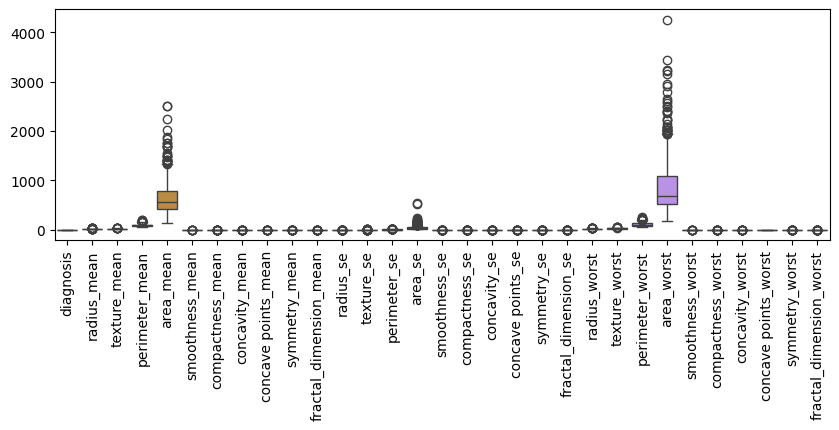

In [95]:
plt.figure(figsize=(10,3))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

# ***Multi Colinearity Occured***

<Axes: >

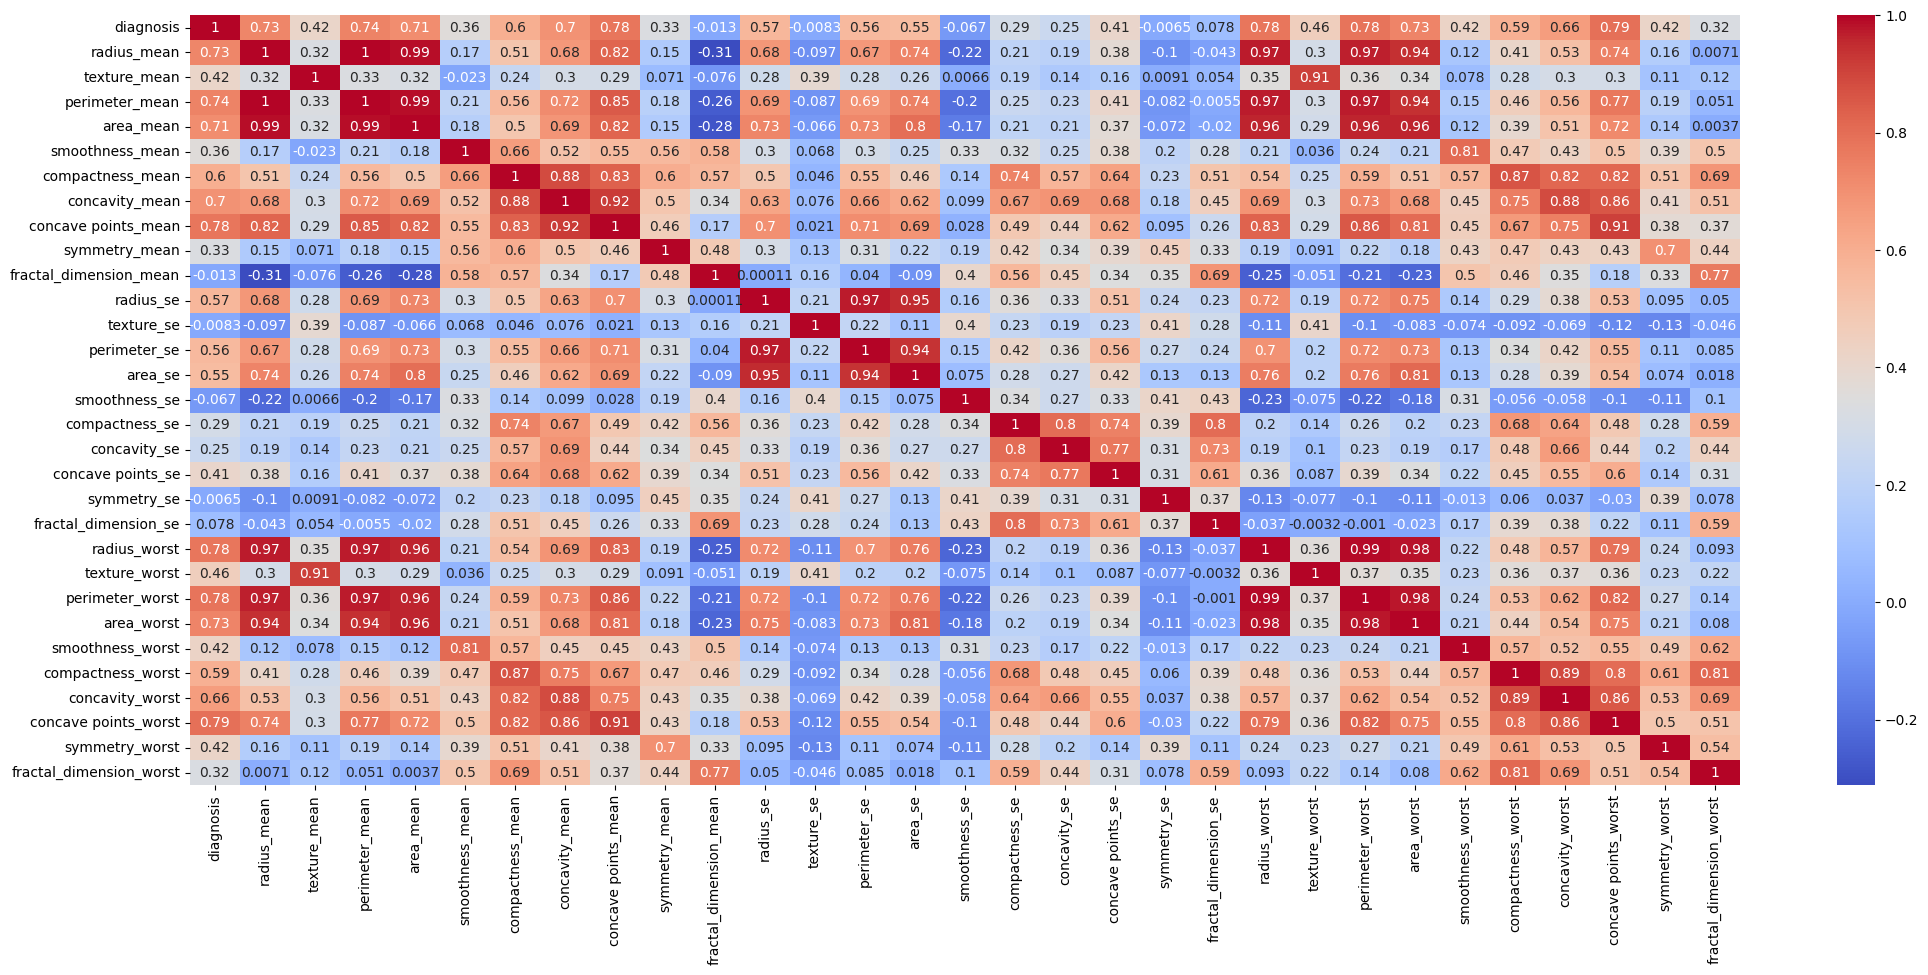

In [96]:
plt.figure(figsize=(25,10))
sns.heatmap(data.corr(), cmap='coolwarm',annot=True)

In [97]:
corr_matrix = data.corr().abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

to_data = [column for column in upper.columns if any(upper[column] > 0.90)]

print(to_data)

['perimeter_mean', 'area_mean', 'concave points_mean', 'perimeter_se', 'area_se', 'radius_worst', 'texture_worst', 'perimeter_worst', 'area_worst', 'concave points_worst']


In [98]:
data= data.drop(columns=to_data)

# ***Multi Colinearity Fixed***

<Axes: >

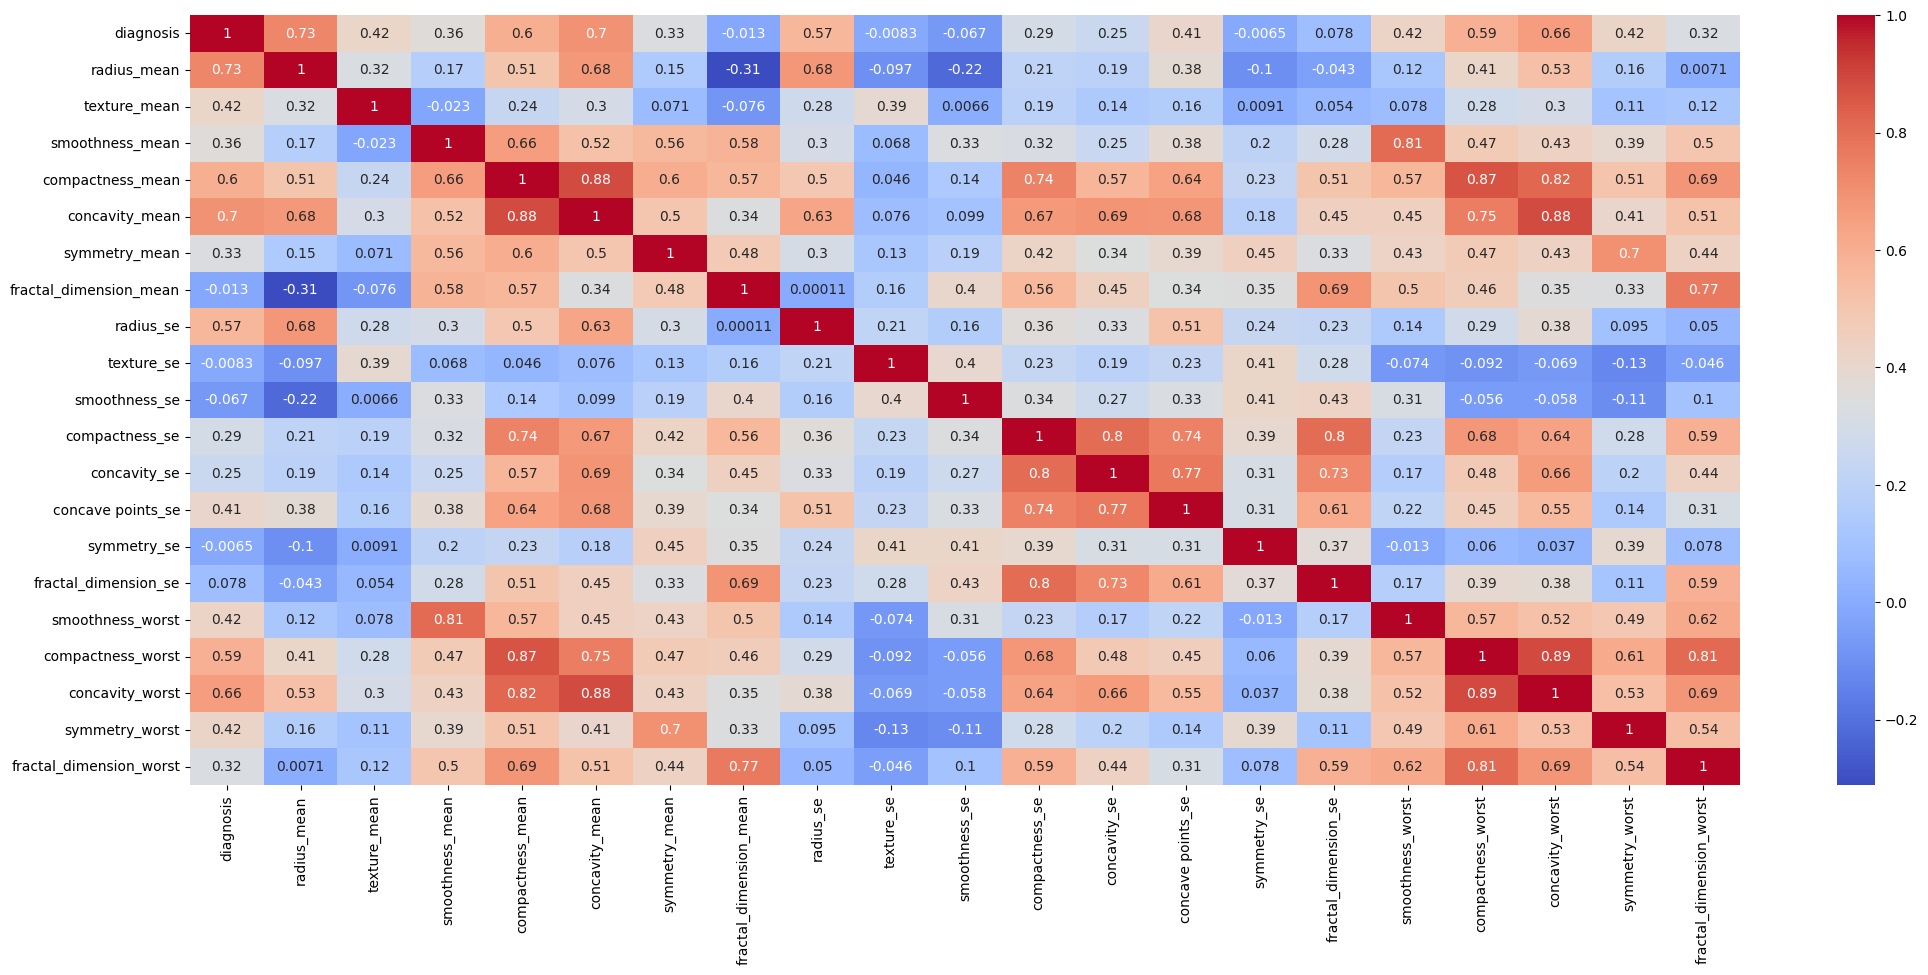

In [99]:
plt.figure(figsize=(25,10))
sns.heatmap(data.corr(), cmap='coolwarm',annot=True)

In [101]:
import numpy as np

for col in data.columns:
    if col != 'diagnosis':
        lower = data[col].quantile(0.01)
        upper = data[col].quantile(0.99)
        data[col] = np.clip(data[col], lower, upper)

# ***Outlier Treated***

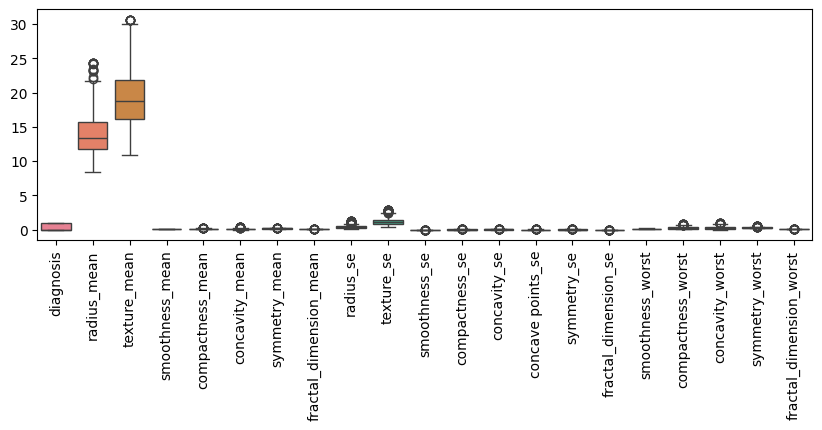

In [102]:
plt.figure(figsize=(10,3))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

In [103]:
# from sklearn.preprocessing import StandardScaler

# scaler = StandardScaler()
# X_scaled = scaler.fit_transform(data.drop('diagnosis', axis=1))

## This was also a way to handle outliers

In [ ]:
# Q1 = data.quantile(0.25)
# Q3 = data.quantile(0.75)
# IQR = Q3 - Q1

# data_clean = data[~((data < (Q1 - 1.5 * IQR)) | (data > (Q3 + 1.5 * IQR))).any(axis=1)]

## This was also a way to handle outliers

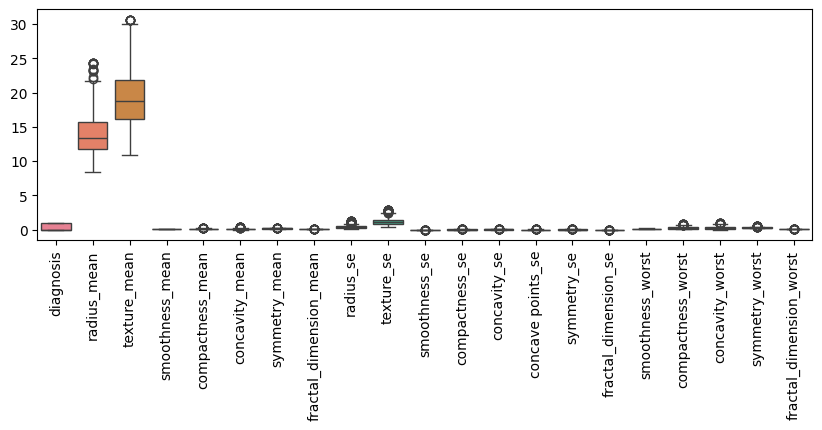

In [106]:
plt.figure(figsize=(10,3))
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

# 4. Visualisation:

●	Perform visualisation on different columns in the dataset

●	Must use: Boxplot, countplot, Heatmap, Pairplot, barplot,Histplot,Scatterplot


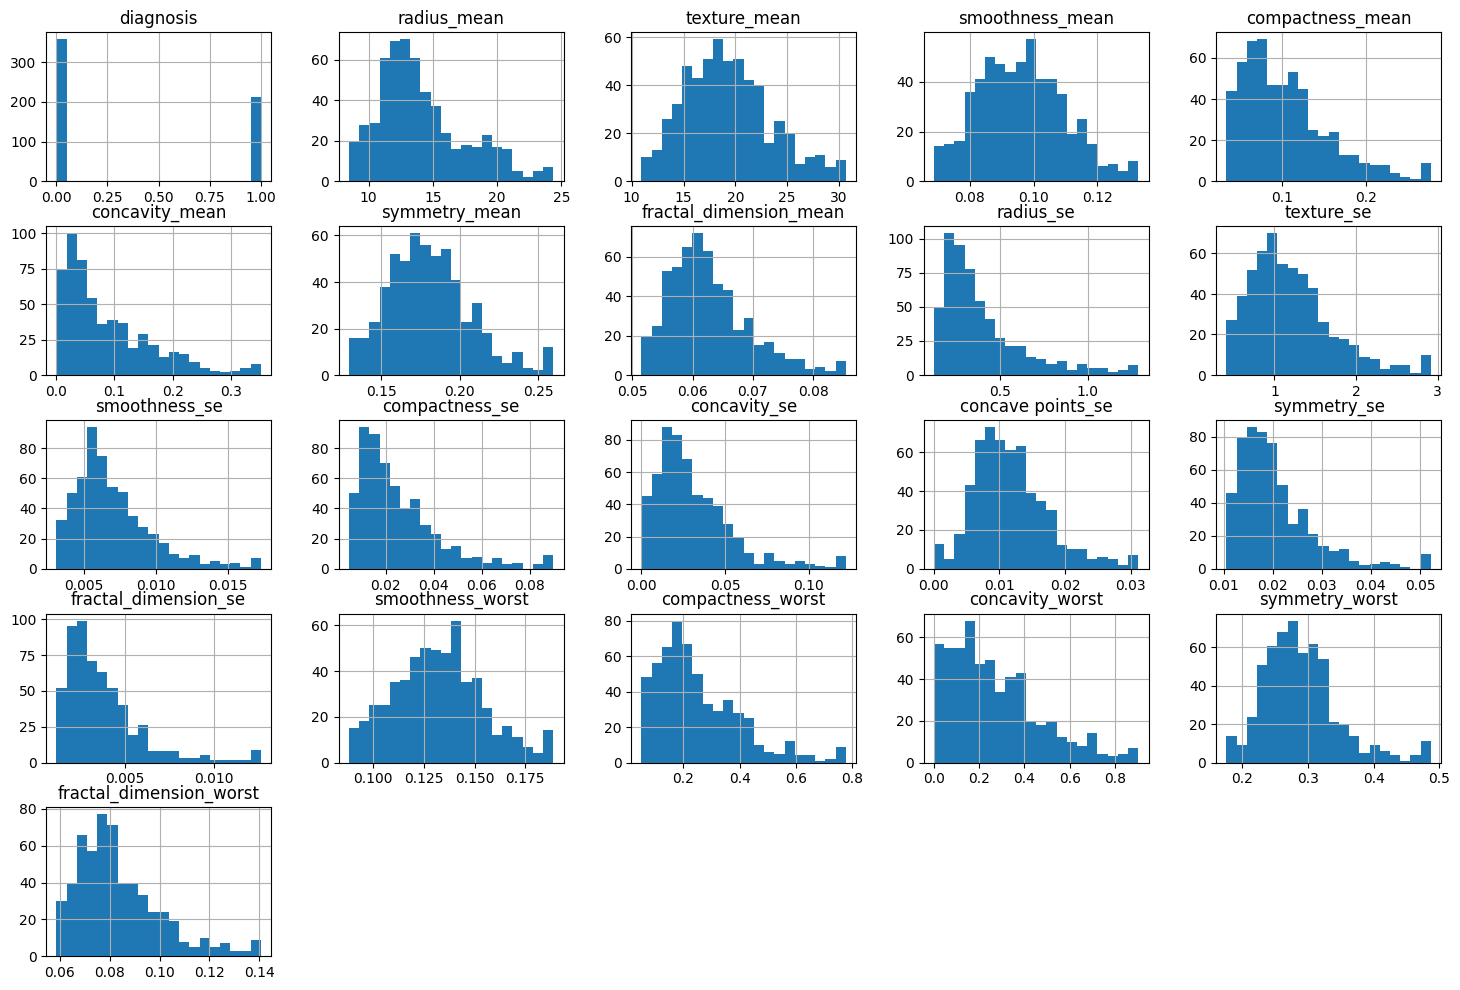

In [108]:
data.hist(figsize=(18,12), bins=20)
plt.show()

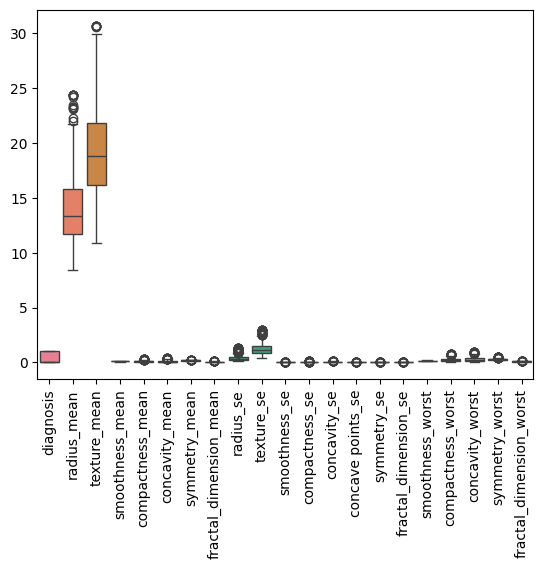

In [109]:
sns.boxplot(data=data)
plt.xticks(rotation=90)
plt.show()

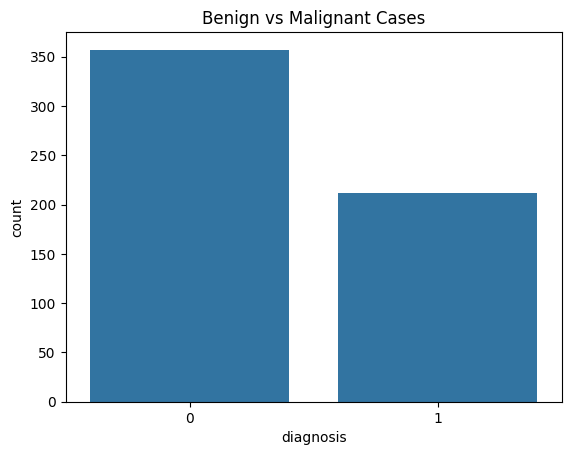

In [110]:
sns.countplot(x='diagnosis', data=data)
plt.title("Benign vs Malignant Cases")
plt.show()

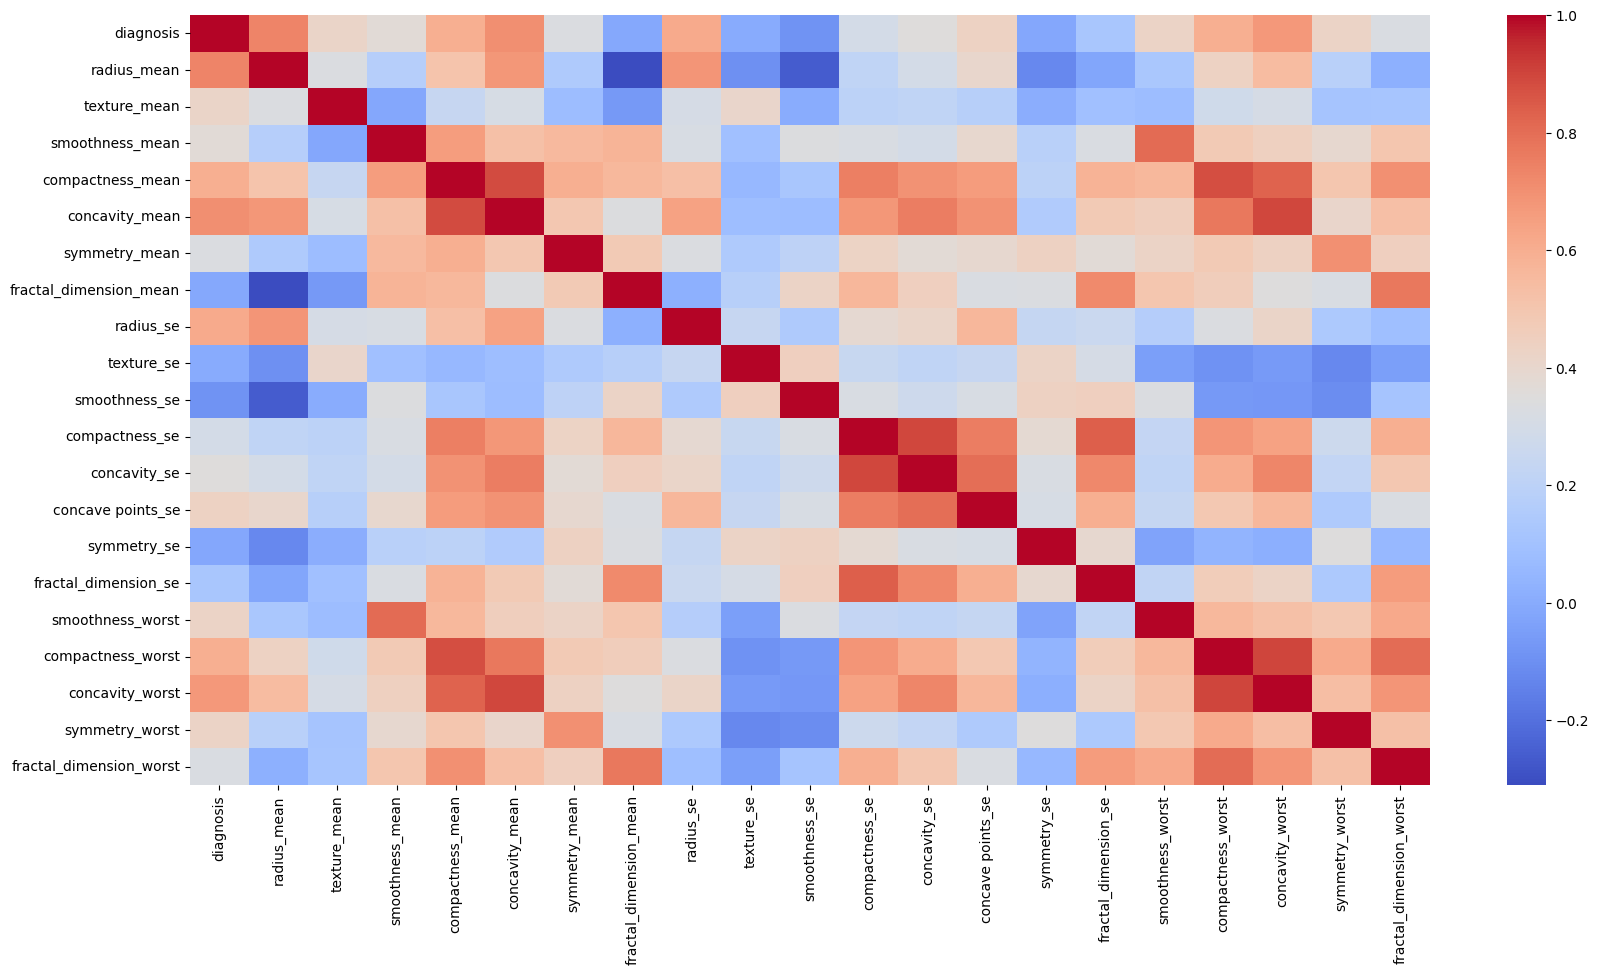

In [111]:
plt.figure(figsize=(20,10))
sns.heatmap(data.corr(), cmap='coolwarm')
plt.show()

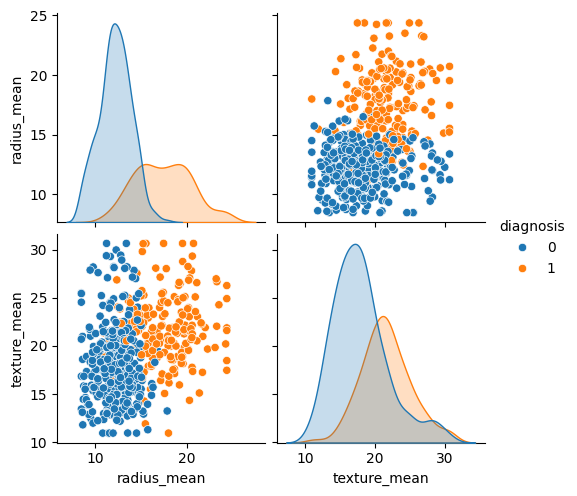

In [112]:
sns.pairplot(data[['diagnosis','radius_mean','texture_mean']], hue='diagnosis')

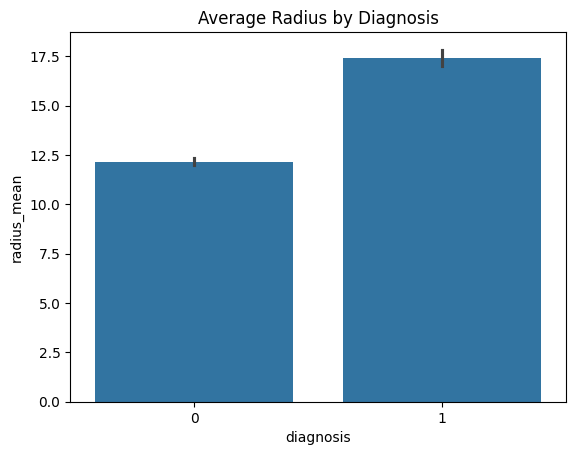

In [113]:
sns.barplot(x='diagnosis', y='radius_mean', data=data)
plt.title("Average Radius by Diagnosis")
plt.show()

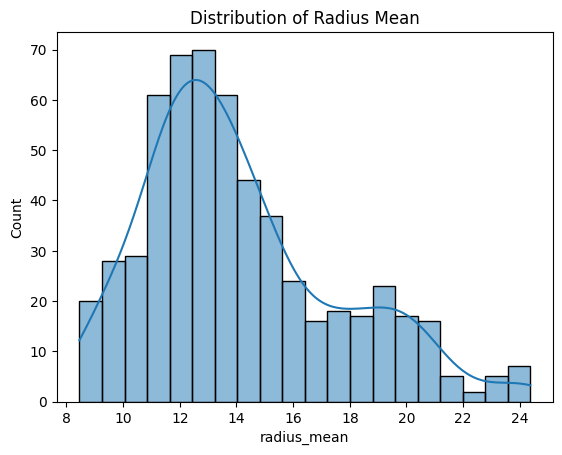

In [114]:
sns.histplot(data['radius_mean'], kde=True, bins=20)
plt.title("Distribution of Radius Mean")
plt.show()

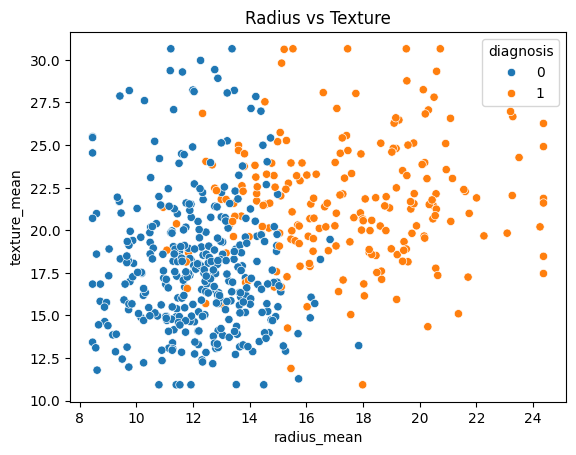

In [115]:
sns.scatterplot(
    x='radius_mean',
    y='texture_mean',
    hue='diagnosis',
    data=data
)
plt.title("Radius vs Texture")
plt.show()

# 5. Feature Scaling

# 6. Model Selection & Fitting:  

●	Train Test split , Fit any 4 model suitable for the dataset and compare the accuracies


In [116]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

X = data.drop('diagnosis', axis=1)
y = data['diagnosis']

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [117]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier

lr = LogisticRegression(max_iter=500)
svm = SVC()
knn = KNeighborsClassifier()
rf = RandomForestClassifier(random_state=42)

lr.fit(X_train_scaled, y_train)
svm.fit(X_train_scaled, y_train)
knn.fit(X_train_scaled, y_train)
rf.fit(X_train, y_train)

RandomForestClassifier(random_state=42)


# 7. Model Evaluation :

●	Classification report, F1 SCORE, Accuracy score, Confusion matrix


In [118]:
from sklearn.metrics import accuracy_score

pred_lr = lr.predict(X_test_scaled)
pred_svm = svm.predict(X_test_scaled)
pred_knn = knn.predict(X_test_scaled)
pred_rf = rf.predict(X_test)

print("Logistic Regression:", accuracy_score(y_test, pred_lr))
print("SVM:", accuracy_score(y_test, pred_svm))
print("KNN:", accuracy_score(y_test, pred_knn))
print("Random Forest:", accuracy_score(y_test, pred_rf))

Logistic Regression: 0.9824561403508771
SVM: 0.9649122807017544
KNN: 0.9473684210526315
Random Forest: 0.9473684210526315


In [119]:
from sklearn.metrics import classification_report
print(classification_report(y_test, pred_lr))
print(classification_report(y_test, pred_svm))
print(classification_report(y_test, pred_knn))
print(classification_report(y_test, pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99        72
           1       1.00      0.95      0.98        42

    accuracy                           0.98       114
   macro avg       0.99      0.98      0.98       114
weighted avg       0.98      0.98      0.98       114

              precision    recall  f1-score   support

           0       0.96      0.99      0.97        72
           1       0.97      0.93      0.95        42

    accuracy                           0.96       114
   macro avg       0.97      0.96      0.96       114
weighted avg       0.97      0.96      0.96       114

              precision    recall  f1-score   support

           0       0.93      0.99      0.96        72
           1       0.97      0.88      0.93        42

    accuracy                           0.95       114
   macro avg       0.95      0.93      0.94       114
weighted avg       0.95      0.95      0.95       114

              preci

In [120]:
from sklearn.metrics import confusion_matrix
print("Logistic Regression:", confusion_matrix(y_test, pred_lr))
print("SVM:", confusion_matrix(y_test, pred_svm))
print("KNN:", confusion_matrix(y_test, pred_knn))
print("Random Forest:", confusion_matrix(y_test, pred_rf))

Logistic Regression: [[72  0]
 [ 2 40]]
SVM: [[71  1]
 [ 3 39]]
KNN: [[71  1]
 [ 5 37]]
Random Forest: [[71  1]
 [ 5 37]]


# ***Additional Steps***

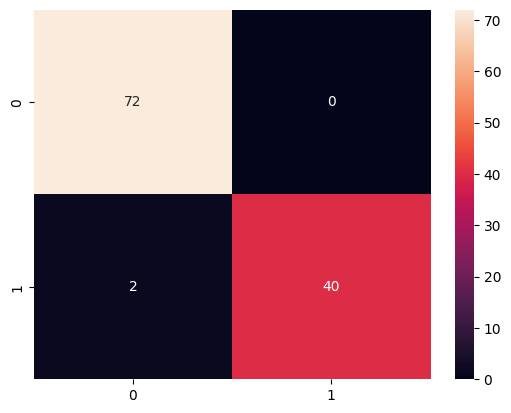

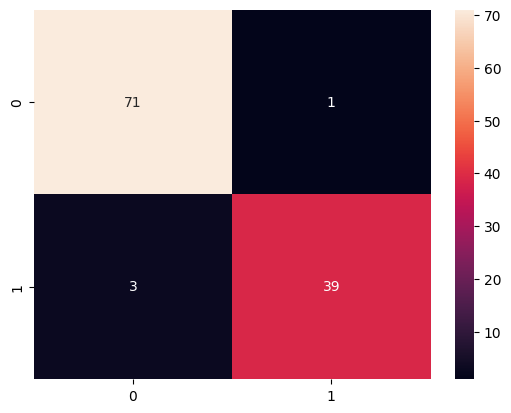

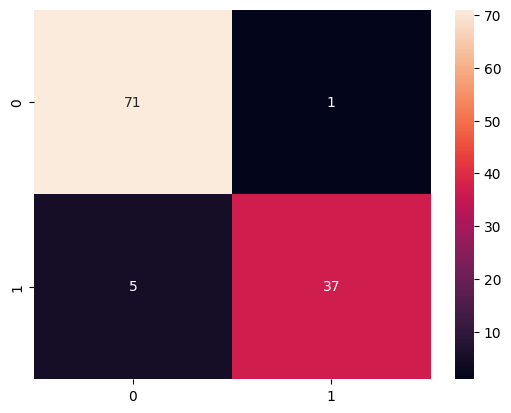

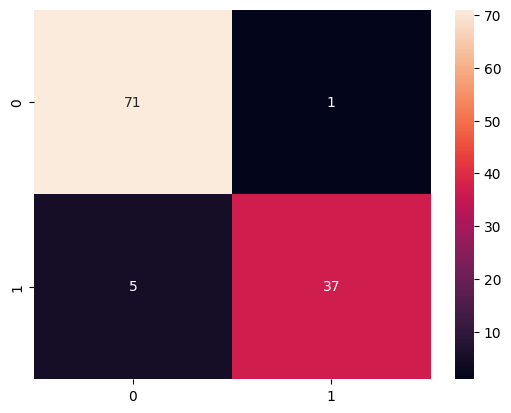

In [121]:
sns.heatmap(confusion_matrix(y_test, pred_lr), annot=True, fmt='d')
plt.show()
sns.heatmap(confusion_matrix(y_test, pred_svm), annot=True, fmt='d')
plt.show()
sns.heatmap(confusion_matrix(y_test, pred_knn), annot=True, fmt='d')
plt.show()
sns.heatmap(confusion_matrix(y_test, pred_rf), annot=True, fmt='d')
plt.show()

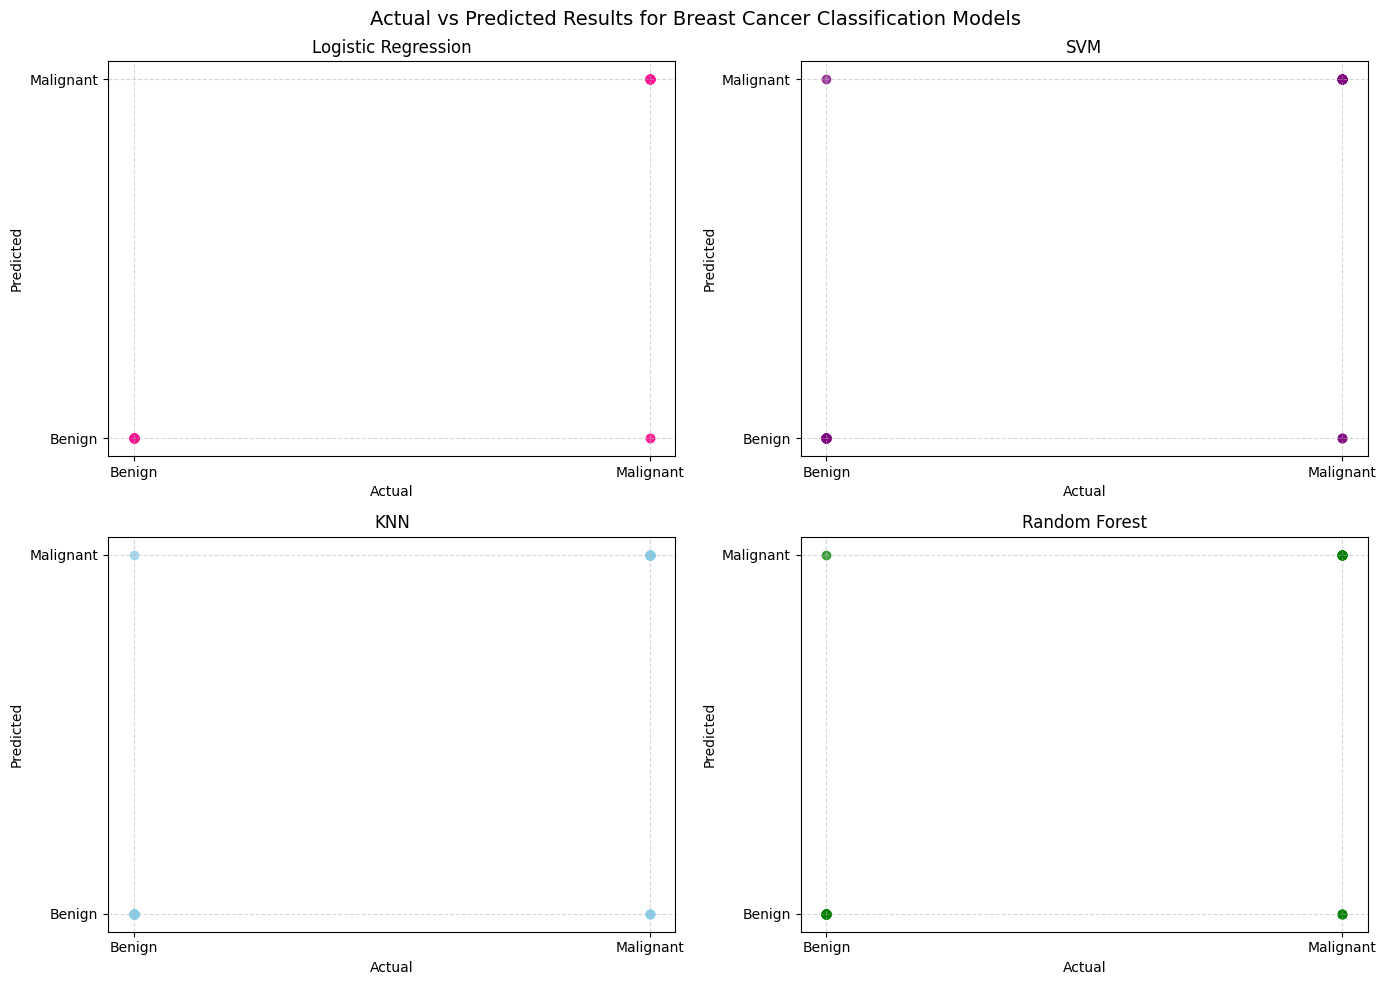

In [122]:
plt.figure(figsize=(14,10))

# Logistic Regression
plt.subplot(2,2,1)
plt.scatter(y_test, pred_lr, color='deeppink', alpha=0.7)
plt.title("Logistic Regression")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xticks([0,1], ['Benign','Malignant'])
plt.yticks([0,1], ['Benign','Malignant'])
plt.grid(True, linestyle='--', alpha=0.5)

# SVM
plt.subplot(2,2,2)
plt.scatter(y_test, pred_svm, color='purple', alpha=0.7)
plt.title("SVM")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xticks([0,1], ['Benign','Malignant'])
plt.yticks([0,1], ['Benign','Malignant'])
plt.grid(True, linestyle='--', alpha=0.5)

# KNN
plt.subplot(2,2,3)
plt.scatter(y_test, pred_knn, color='skyblue', alpha=0.7)
plt.title("KNN")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xticks([0,1], ['Benign','Malignant'])
plt.yticks([0,1], ['Benign','Malignant'])
plt.grid(True, linestyle='--', alpha=0.5)

# Random Forest
plt.subplot(2,2,4)
plt.scatter(y_test, pred_rf, color='green', alpha=0.7)
plt.title("Random Forest")
plt.xlabel("Actual")
plt.ylabel("Predicted")
plt.xticks([0,1], ['Benign','Malignant'])
plt.yticks([0,1], ['Benign','Malignant'])
plt.grid(True, linestyle='--', alpha=0.5)

plt.suptitle("Actual vs Predicted Results for Breast Cancer Classification Models", fontsize=14)
plt.tight_layout()
plt.show()

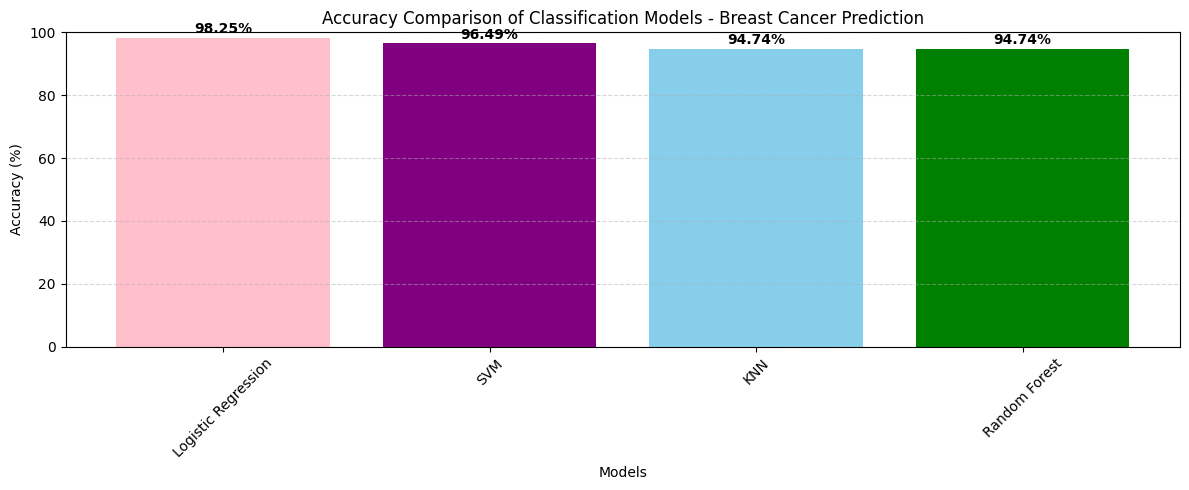

In [123]:
colors = ['pink', 'purple', 'skyblue', 'green']

plt.figure(figsize=(12,5))

bars = plt.bar(model_ev['Model'], model_ev['Accuracy'], color=colors)

plt.title("Accuracy Comparison of Classification Models - Breast Cancer Prediction")
plt.xlabel("Models")
plt.ylabel("Accuracy (%)")

plt.ylim(0, 100)
plt.xticks(rotation=45)

# Show labels on bars
for bar in bars:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2,
             height + 0.5,
             f'{height:.2f}%',
             ha='center',
             va='bottom',
             fontsize=10,
             fontweight='bold')

plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()

plt.show()

## Project Summary / Insights

This project focused on predicting breast cancer diagnosis using machine learning classification techniques. The objective was to classify tumors as **Benign (0)** or **Malignant (1)** based on medical measurement features such as radius, texture, perimeter, area, smoothness, concavity, and related attributes.

---

## 1. Data Understanding

The dataset contained only numerical features with no missing values, making it suitable for machine learning modeling. Most predictor columns were continuous biomedical measurements, so storing them as **float data types** was appropriate rather than integers.

The target variable `diagnosis` was encoded into binary format:

* **0 = Benign**
* **1 = Malignant**

---

## 2. Data Cleaning Performed

### ✔ Null Values

No null values were found, so no imputation was required.

### ✔ Duplicate Values

Duplicates were checked and handled if present.

### ✔ Unnamed Extra Column

An unnecessary unnamed column created during CSV import was removed.

---

## 3. Outlier Analysis & Why Capping Was Used

Boxplots showed outliers mainly in:

* `area_mean`
* `perimeter_mean`
* `radius_mean`
* some `_worst` features

Since this is a **medical dataset**, extreme values may represent genuine tumor cases rather than data errors.

### Why Outliers Were Not Deleted:

Deleting rows using IQR could remove important malignant samples and reduce dataset quality.

### Why Capping Was Used:

Percentile-based capping was applied to reduce extreme influence while preserving all observations.

This improved model stability, especially for:

* Logistic Regression
* SVM
* KNN

---

## 4. Class Imbalance Analysis

Target distribution:

* Class 0 = 357
* Class 1 = 212

This indicates **moderate imbalance**, not severe imbalance.

### Why SMOTE Was Not Applied Initially:

Because the imbalance ratio was manageable, baseline models were first tested using stratified train-test split.

Oversampling was avoided initially to preserve original medical data distribution.

---

## 5. Correlation / Multicollinearity Findings

Heatmap analysis showed high correlation among:

* `radius_mean`
* `perimeter_mean`
* `area_mean`

This is expected because tumor size-related measurements naturally move together.

### Why This Matters:

Multicollinearity can affect:

* Logistic Regression coefficients
* Model interpretability

### Why Features Were Retained:

Tree-based models handle correlated variables well, so all features were initially retained for broader model comparison.

---

## 6. Feature Scaling

Feature values existed on different ranges:

* `area_mean` in hundreds
* `smoothness_mean` near 0.1

### Why Scaling Was Applied:

StandardScaler was used for:

* Logistic Regression
* SVM
* KNN

### Why Scaling Was Not Needed for Random Forest:

Tree-based models are scale-independent.

---

## 7. Model Selection Logic

Four classification models were selected to compare different learning approaches:

| Model               | Why Selected                        |
| ------------------- | ----------------------------------- |
| Logistic Regression | Strong interpretable baseline       |
| SVM                 | High performance on structured data |
| KNN                 | Distance-based benchmark            |
| Random Forest       | Powerful ensemble model             |

This gave a balanced comparison between linear, kernel, instance-based, and ensemble methods.

---

## 8. Evaluation Metrics

Accuracy was used for primary comparison. Since cancer detection is sensitive, recall and F1-score are also important, especially for identifying malignant cases.

False negatives are riskier than false positives in medical diagnosis.

---

## 9. Visualizations Performed

The following charts were used:

* Boxplot → detect outliers
* Countplot → class distribution
* Heatmap → feature correlation
* Pairplot → class separation patterns
* Histplot → distributions
* Scatterplot → feature relationships
* Barplot → model accuracy comparison

---

## 10. Overall Conclusion

The dataset was clean, structured, and highly suitable for machine learning. After preprocessing and model comparison, the project demonstrated how multiple classification algorithms can effectively predict breast cancer diagnosis.

The preprocessing decisions were chosen carefully to preserve valuable medical information while improving model performance.

---

## Final Key Insight

Instead of blindly removing data, preprocessing was done thoughtfully:

* Outliers were capped, not deleted
* Imbalance was monitored, not overcorrected
* Scaling was applied only where necessary
* Models were selected based on dataset behavior

This reflects a practical real-world machine learning workflow rather than just applying random techniques.
